In [1]:
# Step 1: Analyse the data using visualizations

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("D:\\Assignments questions\\KNN\\Zoo.csv")

# Quick overview
print("First 5 rows of dataset:")
print(data.head())
print("\nDataset Info:")
print(data.info())
print("\nSummary Statistics:")
print(data.describe())




First 5 rows of dataset:
  animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   type  
0     1  
1     1  
2     4  
3  

C:\Users\munig\AppData\Local\Temp\ipykernel_16460\673218432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type", data=data, palette="viridis")


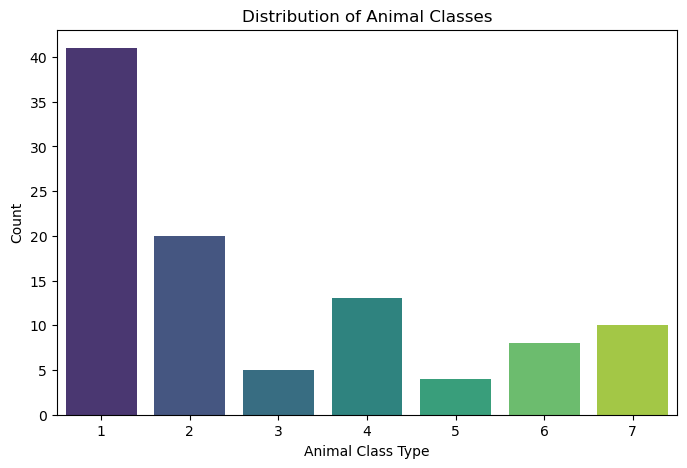

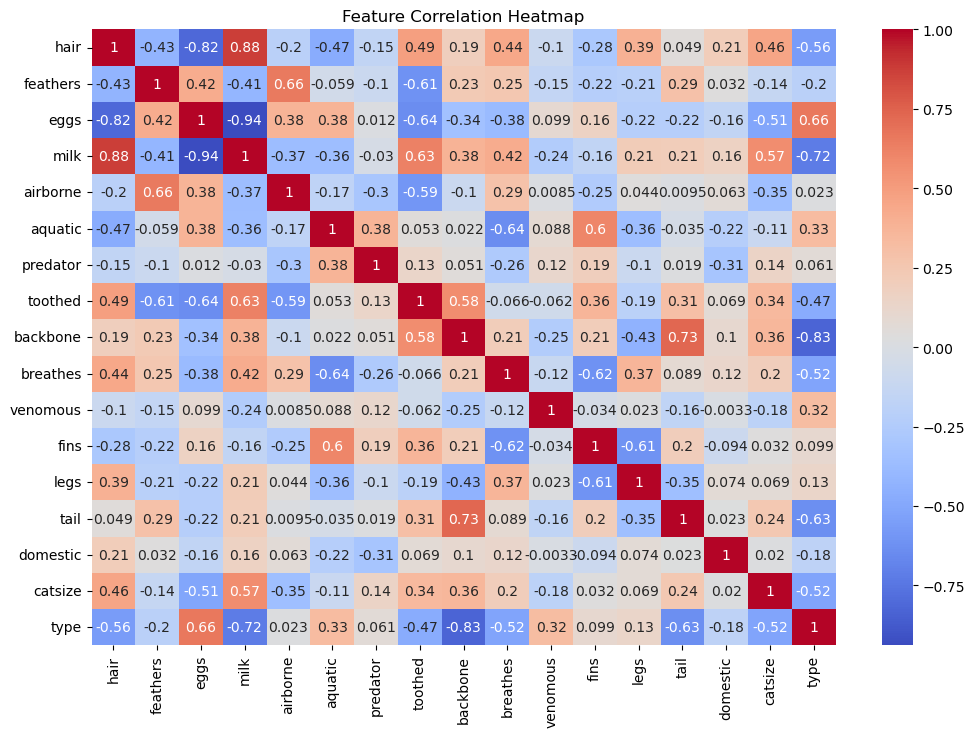

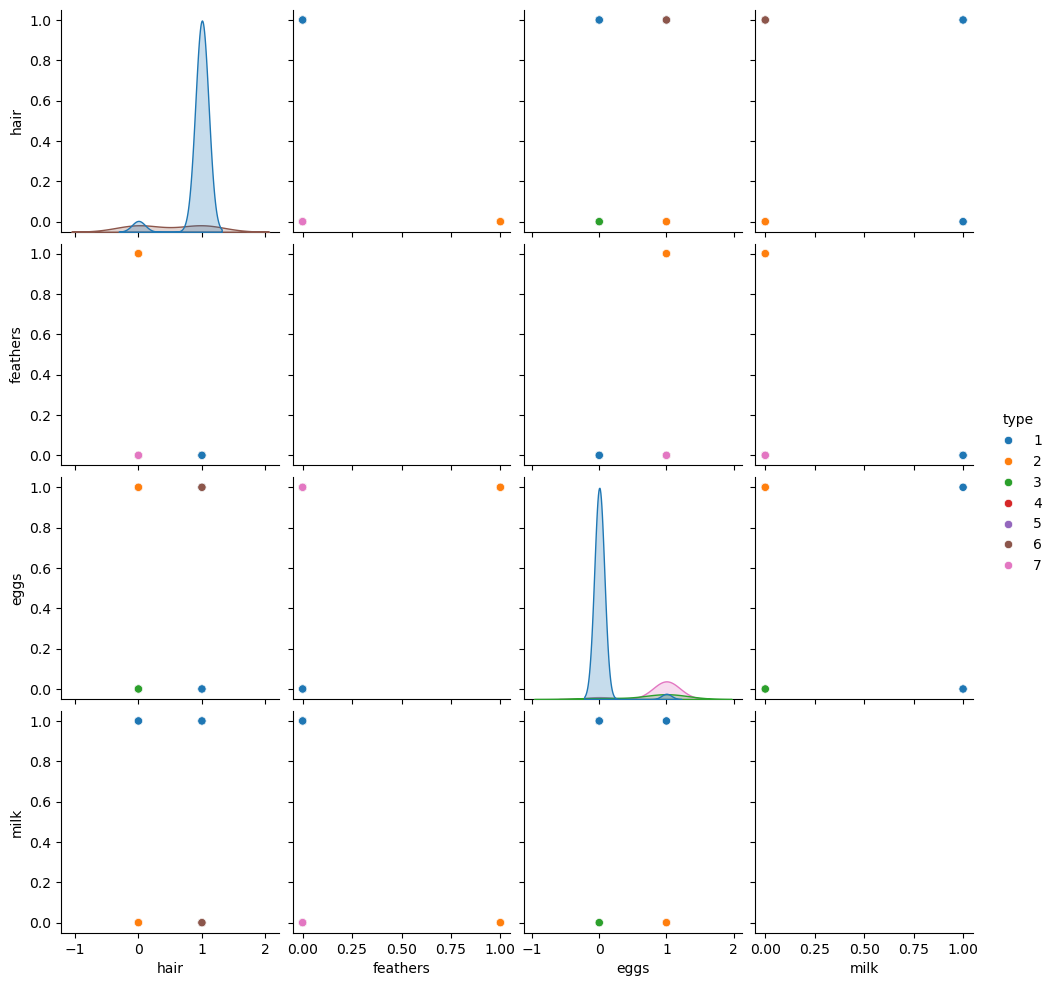

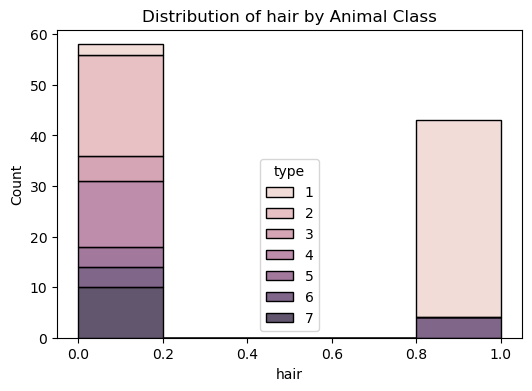

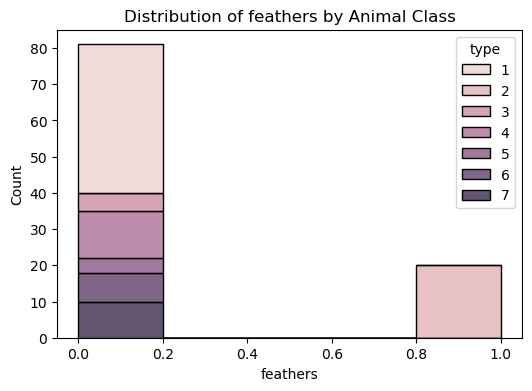

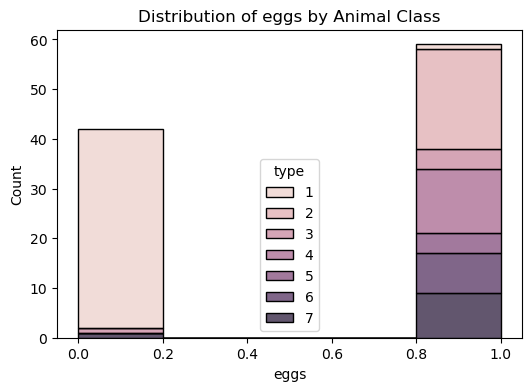

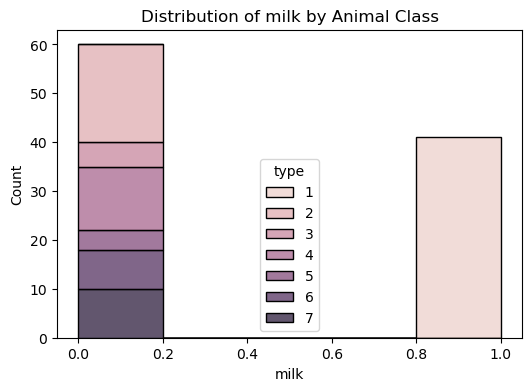

In [8]:
# Check class distribution (animal type)
plt.figure(figsize=(8,5))
sns.countplot(x="type", data=data, palette="viridis")
plt.title("Distribution of Animal Classes")
plt.xlabel("Animal Class Type")
plt.ylabel("Count")
plt.show()

# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=["int64", "float64"])

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot (using correct label column "type")
sns.pairplot(data[["hair", "feathers", "eggs", "milk", "type"]], 
             hue="type", palette="tab10")
plt.show()


# Distribution of selected features
features = ["hair", "feathers", "eggs", "milk"]
for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data, x=col, bins=5, kde=False, hue="type", multiple="stack")

    plt.title(f"Distribution of {col} by Animal Class")
    plt.show()


Missing values in each column:
animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

Number of duplicate rows: 0


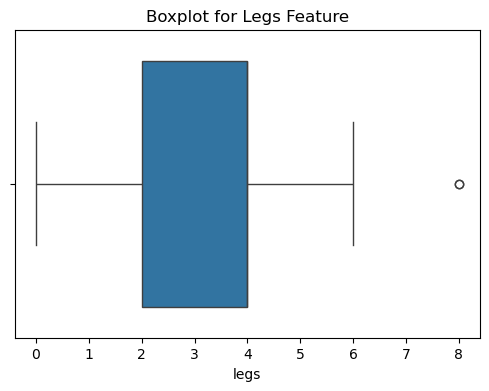

C:\Users\munig\AppData\Local\Temp\ipykernel_16460\1971888596.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="legs", data=data, palette="Set2")


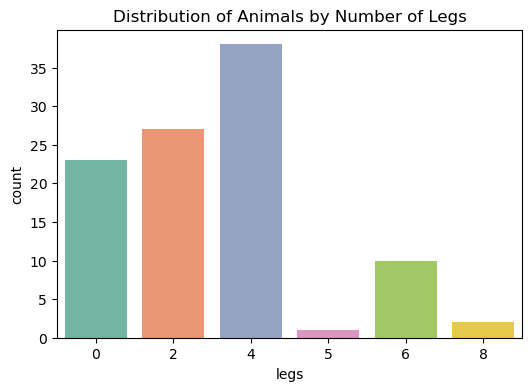


Unique values of 'legs': [4 0 2 6 8 5]

After capping, unique values of 'legs': [4 0 2 6 8 5]


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Check missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

# 2. Check duplicates
print("\nNumber of duplicate rows:", data.duplicated().sum())

# 3. Handle outliers - focus on "legs" (since other features are binary 0/1)
plt.figure(figsize=(6,4))
sns.boxplot(x=data["legs"])
plt.title("Boxplot for Legs Feature")
plt.show()

# Optional: show distribution of legs
plt.figure(figsize=(6,4))
sns.countplot(x="legs", data=data, palette="Set2")
plt.title("Distribution of Animals by Number of Legs")
plt.show()

# 4. Treat outliers if needed (example: if legs > 8, cap them)
# Find max legs
print("\nUnique values of 'legs':", data["legs"].unique())

# Example: Cap any values above 8 (like 100 legs for centipede/spider-like animals)
data["legs"] = data["legs"].apply(lambda x: 8 if x > 8 else x)

print("\nAfter capping, unique values of 'legs':", data["legs"].unique())


In [16]:
# Features = all numeric columns
X = data.select_dtypes(include=["int64", "float64"])

# Target = type column (adjust if named differently)
y = data["type"]

# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (80, 17)
y_train shape: (80,)


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


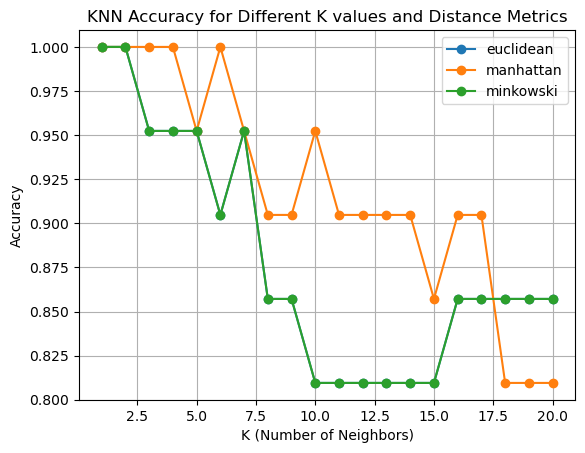

In [18]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Try different values of K
k_values = range(1, 21)   # Test K from 1 to 20
distance_metrics = ["euclidean", "manhattan", "minkowski"]

results = {}

for metric in distance_metrics:
    acc_scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc_scores.append(accuracy_score(y_test, y_pred))
    results[metric] = acc_scores
    plt.plot(k_values, acc_scores, marker="o", label=metric)

plt.title("KNN Accuracy for Different K values and Distance Metrics")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Example: use K=5 and Euclidean distance (replace with your best choice)
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Model Evaluation on Test Set:")
print(f" Accuracy : {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall   : {recall:.4f}")
print(f" F1-Score : {f1:.4f}")

# Detailed per-class performance
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation on Test Set:
 Accuracy : 0.9524
 Precision: 0.9167
 Recall   : 0.9524
 F1-Score : 0.9320

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           0.95        21
   macro avg       0.82      0.86      0.84        21
weighted avg       0.92      0.95      0.93        21



C:\Users\munig\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\munig\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\munig\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\munig\anaconda3\Lib\site-packag

C:\Users\munig\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


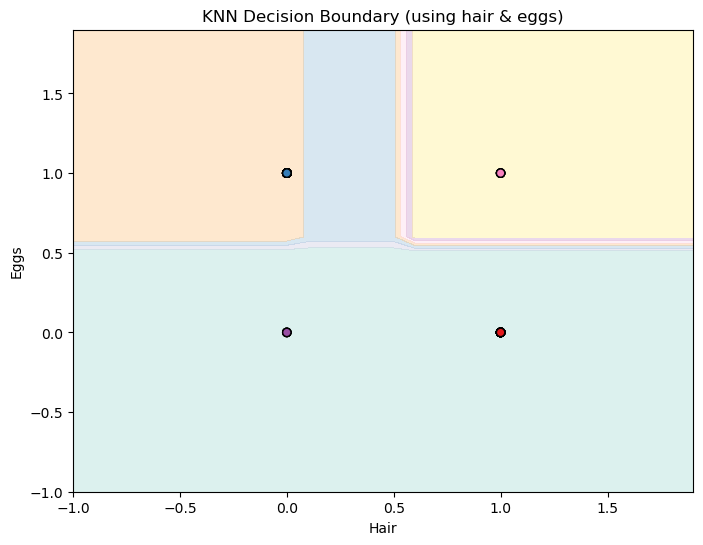

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Choose two features for visualization (e.g., hair vs eggs)
X_vis = data[["hair", "eggs"]]
y_vis = data["type"]

# Train KNN on only 2 features
knn_vis = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_vis.fit(X_vis, y_vis)

# Create meshgrid
x_min, x_max = X_vis["hair"].min() - 1, X_vis["hair"].max() + 1
y_min, y_max = X_vis["eggs"].min() - 1, X_vis["eggs"].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict class for each point in the meshgrid
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)
plt.scatter(X_vis["hair"], X_vis["eggs"], c=y_vis, edgecolor="k", cmap=plt.cm.Set1)
plt.xlabel("Hair")
plt.ylabel("Eggs")
plt.title("KNN Decision Boundary (using hair & eggs)")
plt.show()


In [21]:
'''1. Key Hyperparameters in KNN
n_neighbors (K) → Number of nearest neighbors to consider.
metric → Distance function (Euclidean, Manhattan, etc.).
weights → How neighbors are weighted (uniform = equal, distance = closer neighbors have more influence).
algorithm → Search method (auto, ball_tree, kd_tree, brute).'''


'1. Key Hyperparameters in KNN\nn_neighbors (K) → Number of nearest neighbors to consider.\nmetric → Distance function (Euclidean, Manhattan, etc.).\nweights → How neighbors are weighted (uniform = equal, distance = closer neighbors have more influence).\nalgorithm → Search method (auto, ball_tree, kd_tree, brute).'

In [ ]:
🔹 2. Distance Metrics in KNN
Euclidean distance (L2 norm) – straight-line distance.
Manhattan distance (L1 norm) – sum of absolute differences.
Minkowski distance – generalized form of Euclidean/Manhattan.
Cosine similarity – measures angle between vectors (sometimes used).